# 4 Neural Networks

Our goal is to make 4 neural nets:
1. We have already made the first, out encoder which is an MLP that takes us to 512 ChemNet space
2. An MLP that will take spectra and output toxicity. We also want to make an RF that will do the same
3. An MLP that will take ChemNet embeddings and output toxicity, again we already have a RF that does this, which limited success for unknown chemical compounds.
4. The most complicated, a condiotnal encoder that will intake Spectra and output 516 space, which one hot encoded EPA levels as additinal conditions. This has many further considerations since it will need to peicewise loss function. 


Another condsideration as we start getting these NNs up and running is what problem we want to tackle, multi-class or binary classification and regression are the main two. Additionally we have been using EPA LD50 toxicity levels but the Georgia Institute of Technology indicates that "A substance is considered extremely toxic if it has an LD50 of less than 5 mgs/kg of animal body weight." This could be another bench mark of binary classification, classifying only "extremely toxic" chemicals with LD50 socres below 5. The primary problem that this poses is that there are just VERY few chemicals that fit this description, making major balance issues, compounding the existing problem, as even with an EPA split we see relatively few chemcals of even EPA level 1.

However EPA levels are revealing as "it is Highly toxic if it has an LD50 of between 5 and 50 mg/kg of animal body weight to a human, this would be about a teaspoon." And 50 is the EPA level 1 benchmark, so could also be used as a benchmark for binary classification, however the balance issues would still persist, and they would be inconsistent across groups. 

# General: Functions, Data Upload etc.

## Imports and Globally Used Functions

In [ ]:
# Package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [3]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [4]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [5]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"

In [6]:
# Add the 'Response' and 'log_response' columns THIS IS A UNIVERSAL FUNCTION
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

## Initial Data upload and processing

In [7]:
# The 5/30 dataset with rat based toxicity data and groups
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# This will give us the subsets with all of the relevant information
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 


# Now since I have saved files of the binned specrtra I can simply call those
df3_QQpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQneg_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
df3_LTQOpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
df3_QTOFpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")


(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


In [8]:
# Counts of extrmemly toxic chemicals
num_extremely_toxic = (df3_QQpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QQneg['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_QTOFpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

num_extremely_toxic = (df3_LTQOpos['Response'] < 20).sum()
print(f"Number of SMILES with Response < 10: {num_extremely_toxic}")

Number of SMILES with Response < 10: 15
Number of SMILES with Response < 10: 6
Number of SMILES with Response < 10: 18
Number of SMILES with Response < 10: 8


# Spectra --> ChemNet Encoder

### Functions

In [9]:
# This is our default function, the one we use to prep the data for the encoder that takes us from spectra to ChemNet encodings 
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

### Architecture

In [10]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 5

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_encoder(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss) and loss2 (toxicity loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training

In [11]:
# Training and validation dataset split 
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QQpos = train_data
test_data_df3_QQpos = test_data
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 681)
(579, 681)


In [12]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 681)
After removal, test shape: (538, 681)
Super testing set shape: (86, 681)
Any left in train? False
Any left in test? False


In [13]:
# # Verification of the number of training and testing SMILES present
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQpos = train_data_df3_QQpos[train_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQpos = test_data_df3_QQpos[test_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())

In [14]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos
val_data = test_data

In [15]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model_encoder(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22681.0 MB
  Memory Used: 1536.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090


/tmp/ipykernel_2049141/1290308847.py:38: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)


Epoch [1/500]
   Training loss: 0.0883236676454544
   Validation loss: 0.01823733188211918
Epoch [2/500]
   Training loss: 0.07621464216046864
   Validation loss: 0.015734808519482613
Epoch [3/500]
   Training loss: 0.06826214740673701
   Validation loss: 0.014393776655197144
Epoch [4/500]
   Training loss: 0.0634321884976493
   Validation loss: 0.013707250356674194
Epoch [5/500]
   Training loss: 0.06085413280460569
   Validation loss: 0.012944592162966728
Epoch [6/500]
   Training loss: 0.059093778745995626
   Validation loss: 0.013555411249399185
Epoch [7/500]
   Training loss: 0.05702967610624102
   Validation loss: 0.012663260102272034
Epoch [8/500]
   Training loss: 0.05470440909266472
   Validation loss: 0.01209632121026516
Epoch [9/500]
   Training loss: 0.05219726264476776
   Validation loss: 0.01249266043305397
Epoch [10/500]
   Training loss: 0.04903646185994148
   Validation loss: 0.01135959755629301
Epoch [11/500]
   Training loss: 0.04577388655808237
   Validation loss: 0

### Testing

In [16]:
# This is simply excecuting a test of the encoder, we do this process again down below when we want the encoder ouputs to be MLP inputs.
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



# Spectra --> Toxicity MLP and Random Forest

### Processing

In [70]:
# Add the 'Response' column using the SMILES as an identifier
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

df3_QQpos_spectra = add_response_column_to_spectra(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra') # Add response (needed to add EPA)

# Add EPA levels (one-hot encoded)
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    df["EPA_level"] = df[response_col].apply(assign_func)
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    df.drop(columns=[response_col], inplace=True)
    return df

df3_QQpos_spectra_withEPA = add_epa_levels(df3_QQpos_spectra) # Add EPA, and then check to make sure
df3_QQpos_spectra_withEPA.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,675,676,677,678,679,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0


In [71]:
# Super test removal, same as we had before with a even mix of EPA levels, though not all of these are in each group subset of the data.

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
super_testing_df3_QQpos = df3_QQpos_spectra_withEPA[df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
df3_QQpos_spectra_withEPA = df3_QQpos_spectra_withEPA[~df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, shape:", df3_QQpos_spectra_withEPA.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any leff?", any(df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)))


After removal, shape: (1218, 685)
Super testing set shape: (89, 685)
Any leff? False


In [72]:
super_testing_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,675,676,677,678,679,log_response,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.611823,0,1,0,0


### Random Forest Classifier

In [19]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QQpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QQpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     24
EPA_level_2    239
EPA_level_3    720
EPA_level_4    235
dtype: int64


In [20]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QQpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QQpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

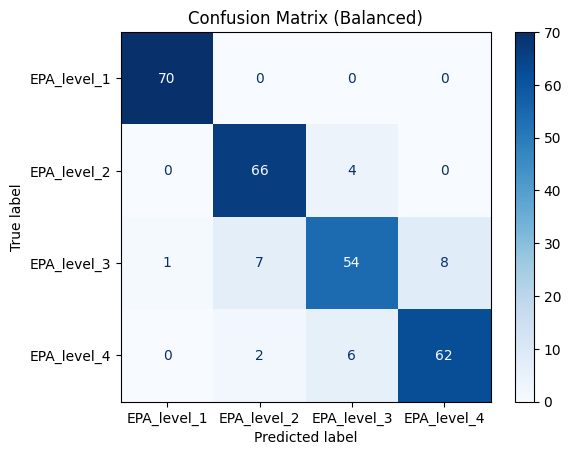

In [21]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Spectra to Toxicity MLP Architecture

In [59]:
#%%
# Everything below this line SHOULD be able to run without modification
class SpecToxMLP_Reg(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP_spectra(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP data processing

In [92]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

# Save the dataframes with more descriptive names
train_data_df3_QQpos = train_data.copy()
test_data_df3_QQpos = test_data.copy()
val_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

In [90]:
# This isolates log response as the target varaible, not including embeddings at all.
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### MLP training

In [95]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)


Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22132.0 MB
  Memory Used: 2084.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


In [97]:
#%%
SpecToxMLP_df3_QQpos = SpecToxMLP_Reg(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

batch_size = 128
epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10


#%%
SpecToxMLP_model_df3_QQpos = train_model_MLP_spectra(
    model=SpecToxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

Epoch [1/1000]
   Training loss: 56.42128372192383
   Validation loss: 24.373228073120117
Epoch [2/1000]
   Training loss: 56.22541122436523
   Validation loss: 25.0002384185791
Epoch [3/1000]
   Training loss: 55.338731384277345
   Validation loss: 23.996261596679688
Epoch [4/1000]
   Training loss: 53.25012435913086
   Validation loss: 22.121910095214844
Epoch [5/1000]
   Training loss: 47.68406600952149
   Validation loss: 18.408626556396484
Epoch [6/1000]
   Training loss: 34.17492599487305
   Validation loss: 10.037981033325195
Epoch [7/1000]
   Training loss: 15.678560829162597
   Validation loss: 9.186209678649902
Epoch [8/1000]
   Training loss: 12.716466999053955
   Validation loss: 5.964188098907471
Epoch [9/1000]
   Training loss: 8.467298316955567
   Validation loss: 3.6442649364471436
Epoch [10/1000]
   Training loss: 8.375553226470947
   Validation loss: 3.5365607738494873
Epoch [11/1000]
   Training loss: 6.513319492340088
   Validation loss: 3.9501845836639404
Epoch [12

### Spectra MLP on super test set

In [106]:
# Ensure model and tensor are on the same device
model_device = next(SpecToxMLP_model_df3_QQpos.parameters()).device

# Get the X and Y values
spectra_super = super_testing_df3_QQpos.iloc[:, 1:-5]  # To remove the EPA levels
log_tox_val_super = super_testing_df3_QQpos['log_response']  # To get the log response

# Convert the spectra to a tensor 
x_val_super_test = torch.Tensor(spectra_super.values).to(model_device)

# Now we can run the model on the super test set
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    super_test_output = SpecToxMLP_model_df3_QQpos(x_val_super_test)

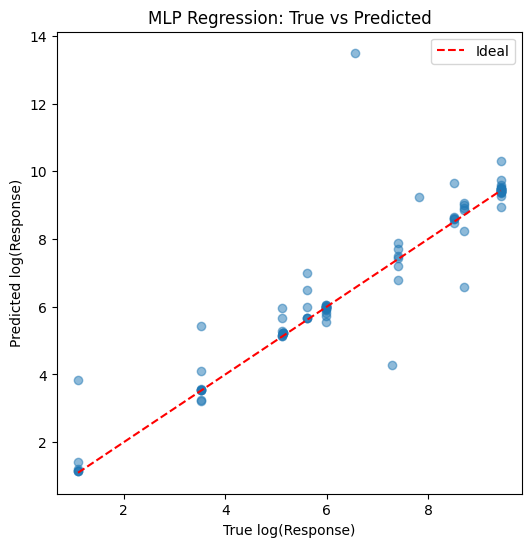

Mean Squared Error: 0.9410
R^2 Score: 0.8404


In [107]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = log_tox_val_super
y_pred = super_test_output.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

/home/dlipsey/.local/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


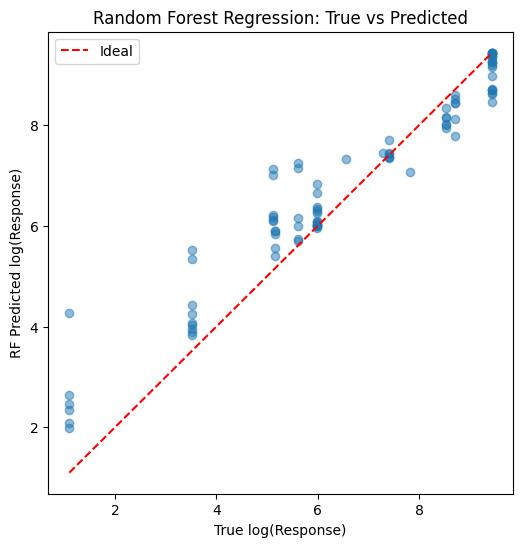

Random Forest Mean Squared Error: 0.6313
Random Forest R^2 Score: 0.8929


In [110]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)


# Predict on super test set
y_pred_rf = rf_reg.predict(spectra_super)
y_true = log_tox_val_super

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred_rf, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_true, y_pred_rf)
r2_rf = r2_score(y_true, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

### MLP Evaluation

In [63]:
# Spectra to tox MLP evaluation
SpecToxMLP_model_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = SpecToxMLP_model_df3_QQpos(x_val)  


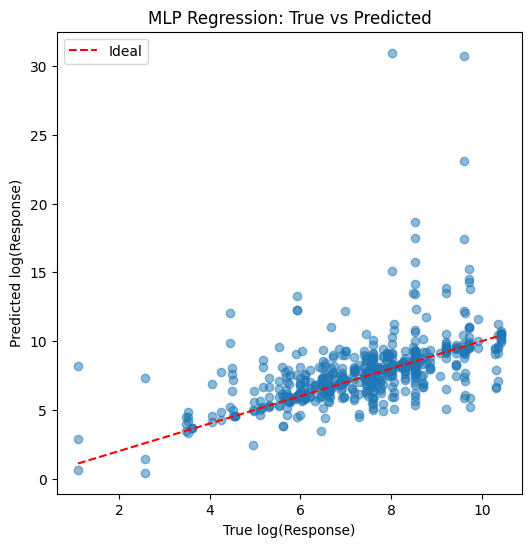

Mean Squared Error: 4.9582
R^2 Score: -0.9377


In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Scatter plot: predicted vs true
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

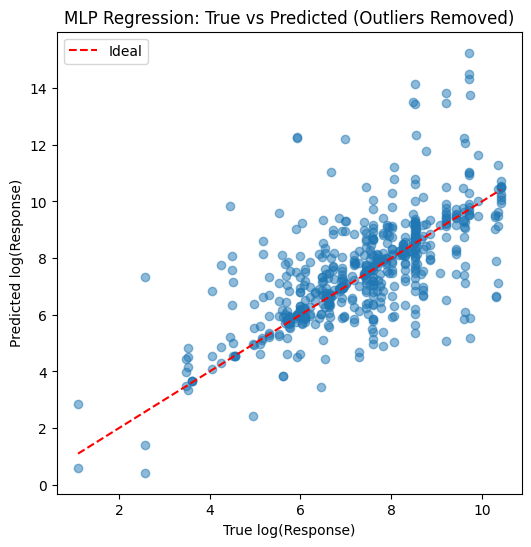

Mean Squared Error (filtered): 2.1224
R^2 Score (filtered): 0.1462


In [65]:
# Convert tensors to numpy arrays
y_true = y_val_tox.cpu().numpy().flatten()
y_pred = test_output_df3_QQpos.cpu().numpy().flatten()

# Remove outliers: keep only points within 3 standard deviations of the residuals
residuals = y_true - y_pred
std_res = np.std(residuals)
mask = np.abs(residuals) < 3 * std_res
y_true_filtered = y_true[mask]
y_pred_filtered = y_pred[mask]

# Scatter plot: predicted vs true (filtered)
plt.figure(figsize=(6,6))
plt.scatter(y_true_filtered, y_pred_filtered, alpha=0.5)
plt.plot([y_true_filtered.min(), y_true_filtered.max()], [y_true_filtered.min(), y_true_filtered.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('MLP Regression: True vs Predicted (Outliers Removed)')
plt.legend()
plt.show()

# Quantitative metrics (filtered)
mse = mean_squared_error(y_true_filtered, y_pred_filtered)
r2 = r2_score(y_true_filtered, y_pred_filtered)
print(f"Mean Squared Error (filtered): {mse:.4f}")
print(f"R^2 Score (filtered): {r2:.4f}")

In [66]:
print(y_pred.shape)
print(y_true.shape)
print(y_true_filtered.shape)
print(y_pred_filtered.shape)

(579,)
(579,)
(568,)
(568,)


### Random forest regressor

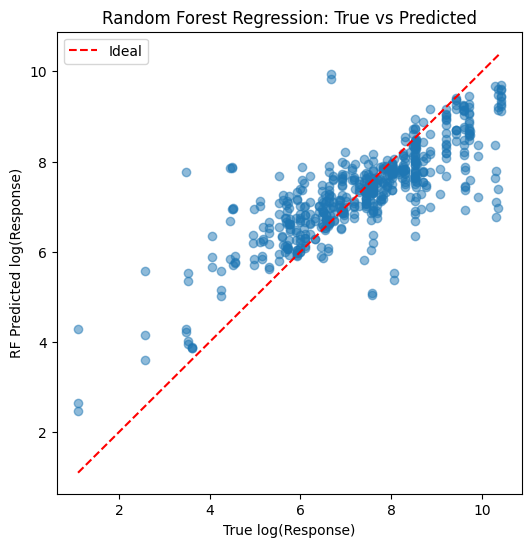

Random Forest Mean Squared Error: 0.9426
Random Forest R^2 Score: 0.6316


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Convert tensors to numpy arrays for sklearn
X_train = x_train.cpu().numpy()
y_train = y_train_tox.cpu().numpy().flatten()
X_test = x_val.cpu().numpy()
y_test = y_val_tox.cpu().numpy().flatten()

# Train the Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_reg.predict(X_test)

# Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Quantitative metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# ChemNet --> Toxicity MLP and Random Forest

### Processing to/of ChemNet Embeddings

In [ ]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# # Encoder excecution df3_QQpos super testing
# x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
# x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
# encoder_df3_QQpos.eval()
# with torch.no_grad():
#     super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)


In [ ]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos['SMILES_spectra']


In [ ]:
# Add the 'Response' values to the test and train outputs
# def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
#     """
#     Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
#     """
#     # Create mapping from SMILES to Response
#     smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
#     output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
#     return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')


In [ ]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    df.drop(columns=[response_col], inplace=True)
    return df

# Example usage for all your DataFrames:
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

In [ ]:
# # Process encoder outputs for all 4 super test sets
# # QQpos
# super_test_output_df3_QQpos_np = super_test_output_df3_QQpos.cpu().numpy()
# super_test_output_df3_QQpos_df = pd.DataFrame(
#     super_test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQpos_np.shape[1])]
# )
# super_test_output_df3_QQpos_df['SMILES_spectra'] = super_testing_df3_QQpos['SMILES_spectra'].values

# # Add the 'Response' column using the original dataframes
# super_test_output_df3_QQpos_df = add_response_column(super_test_output_df3_QQpos_df, df3_QQpos, smiles_col='SMILES_spectra')

# # Add EPA levels (one-hot) and remove 'Response'
# super_test_output_df3_QQpos_withEPA = add_epa_levels(super_test_output_df3_QQpos_df)


In [ ]:
# # Make the dataframes that we will use a train set, a test set, and a combined set
# train_concat = pd.concat([
#     train_output_df3_QQpos_withEPA,
#     train_output_df3_QQneg_withEPA,
#     train_output_df3_QTOFpos_withEPA,
#     train_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

# test_concat = pd.concat([
#     test_output_df3_QQpos_withEPA,
#     test_output_df3_QQneg_withEPA,
#     test_output_df3_QTOFpos_withEPA,
#     test_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

# combined_concat = pd.concat([train_concat, test_concat], ignore_index=True)

# print("Train shape:", train_concat.shape)
# print("Test shape:", test_concat.shape)
# print("Combined shape:", combined_concat.shape)

# # Super test concatonation
# super_test_concat = pd.concat([
#     super_test_output_df3_QQpos_withEPA,
#     super_test_output_df3_QQneg_withEPA,
#     super_test_output_df3_QTOFpos_withEPA,
#     super_test_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

### Random Forest

In [ ]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QQpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     16
EPA_level_2    117
EPA_level_3    308
EPA_level_4     97
dtype: int64


In [ ]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [ ]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QQpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

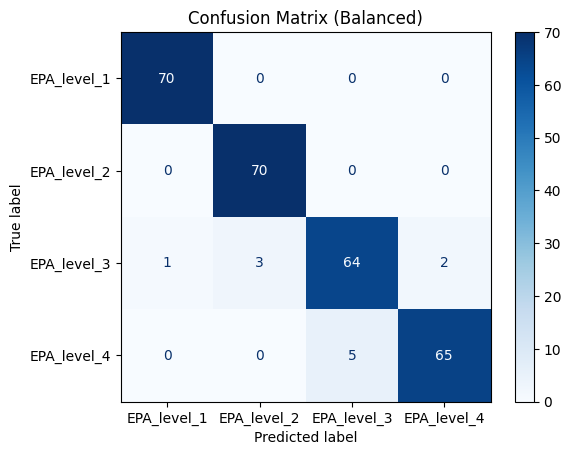

In [ ]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Neural Network Data Processing

In [ ]:
# First we will need to adjust the data so that we have included the log of response.

# Run the encoder
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QQpos = add_response_and_log_response(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_and_log_response(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')


# Add an index for bette integration into the MLP algorithm
test_output_df3_QQpos['index'] = test_output_df3_QQpos.index
train_output_df3_QQpos['index'] = train_output_df3_QQpos.index

# Save a copy
test_output_df3_QQpos_copy = test_output_df3_QQpos.copy()
train_output_df3_QQpos_copy = train_output_df3_QQpos.copy()

In [ ]:
test_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.120772,-0.000136,0.080763,0.379209,-0.071863,0.061572,-0.140726,-0.418325,-0.432292,-0.262067,...,0.065422,-0.010482,-0.429987,0.178499,0.167797,0.141658,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.087540,-0.007020,-0.123977,0.332417,-0.026116,0.072075,-0.059056,-0.628226,-0.619481,-0.516887,...,-0.183324,-0.280353,-0.589240,0.034286,0.027931,0.234057,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.082893,0.001387,-0.117758,0.365346,-0.016832,0.066487,-0.076438,-0.651058,-0.633666,-0.515996,...,-0.205744,-0.293388,-0.600864,0.043300,0.061559,0.240338,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,0.330512,-0.010539,0.115465,0.629430,-0.136697,0.145881,-0.410593,-0.037280,0.009531,0.097763,...,0.157936,0.163897,0.352003,0.574449,0.111251,0.423616,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,0.350696,-0.000849,0.107821,0.625544,-0.118620,0.118826,-0.420824,-0.047082,0.000999,0.082376,...,0.134541,0.167444,0.319362,0.615316,0.152071,0.397173,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


In [ ]:
train_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.091075,-0.001156,-0.088764,0.359521,-0.020842,0.073807,-0.082142,-0.621827,-0.612913,-0.491890,...,-0.175912,-0.253151,-0.586400,0.059665,0.073463,0.225338,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.081309,-0.000818,-0.125810,0.376222,-0.017967,0.061669,-0.080106,-0.657835,-0.632684,-0.519487,...,-0.211895,-0.310372,-0.600482,0.025853,0.048279,0.247680,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.086095,-0.007048,-0.123833,0.329594,-0.026123,0.072431,-0.058754,-0.627162,-0.619159,-0.517190,...,-0.182256,-0.278856,-0.590106,0.036983,0.029852,0.232899,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,0.341716,-0.002307,0.109080,0.627163,-0.113497,0.109135,-0.417542,-0.040078,-0.009676,0.092365,...,0.149714,0.153246,0.323716,0.608451,0.147043,0.404417,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,0.351987,0.002099,0.109448,0.620533,-0.125442,0.129352,-0.413380,-0.045401,0.001792,0.082415,...,0.141448,0.167896,0.326385,0.605281,0.137902,0.403439,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


### Neural Network Architecture

In [ ]:
# The genreal architecture of the MLP will be the same as that of the encoder, the main difference between the two is that the MLP will 
# have a 1 dimensional output, the true Response values of each SMILES, and we will use those SMILES to track which repsonse value belongs 
# with each Chemical.
# We will also adjust the input so that we have the log(response) rather than just response as our varaible of interest.

#%%
epochs=100
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 5
#%%

# Everything below this line SHOULD be able to run without modification
class ToxMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_MLP(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### Neural Network Data Prep

In [ ]:
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-4]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### Training of the MLP

In [ ]:
# MLP training
device = f.set_up_gpu()
# Name the dataset I use correctly
train_data = train_output_df3_QQpos
val_data = test_output_df3_QQpos

# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QQpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QQpos = train_model_MLP(
    model=toxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22094.0 MB
  Memory Used: 2122.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/100]
   Training loss: 55.02035751342773
   Validation loss: 10.48514461517334
Epoch [2/100]
   Training loss: 53.94794273376465
   Validation loss: 10.285414695739746
Epoch [3/100]
   Training loss: 52.43416213989258
   Validation loss: 10.661325454711914
Epoch [4/100]
   Training loss: 47.61999244689942
   Validation loss: 8.72742748260498
Epoch [5/100]
   Training loss: 37.90248680114746
   Validation loss: 6.840065956115723
Epoch [6/100]
   Training loss: 19.81776909828186
   Validation loss: 1.9234144687652588
Epoch [7/100]
   Training loss: 5.016743731498718
   Validation loss: 0.484466552734375
Epoch [8/100]
   Training loss: 4.921633291244507
   Validation loss: 0.5071256756782532
Epoch [9/100]
   Training loss: 3.000587296485901
   Validation 

### Evaluation of the MLP

In [ ]:
# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_test_output_df3_QQpos = toxMLP_df3_QQpos(x_val) 

# Excecution
MLP_model_df3_QQpos.eval()
with torch.no_grad():
    ChemNet_MLP_train_output_df3_QQpos = toxMLP_df3_QQpos(x_train)  
 

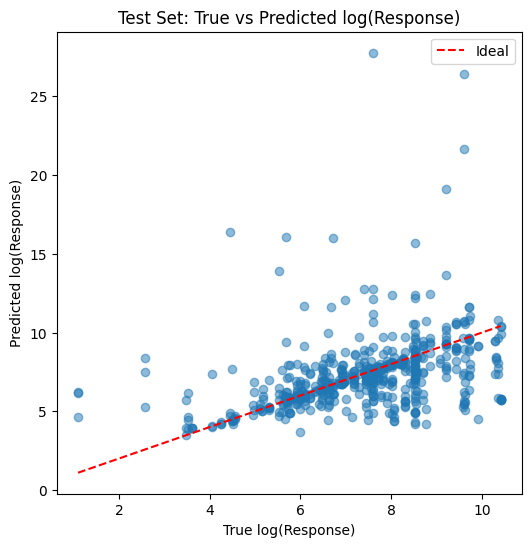

Test Set Mean Squared Error: 5.0072
Test Set R^2 Score: -0.9569


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

# Use the correct source for true values
y_true_test = test_output_df3_QQpos_copy['log_response'].values
y_pred_test = ChemNet_MLP_test_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_test, y_pred_test, alpha=0.5)
plt.plot([y_true_test.min(), y_true_test.max()], [y_true_test.min(), y_true_test.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_test = mean_squared_error(y_true_test, y_pred_test)
r2_test = r2_score(y_true_test, y_pred_test)
print(f"Test Set Mean Squared Error: {mse_test:.4f}")
print(f"Test Set R^2 Score: {r2_test:.4f}")


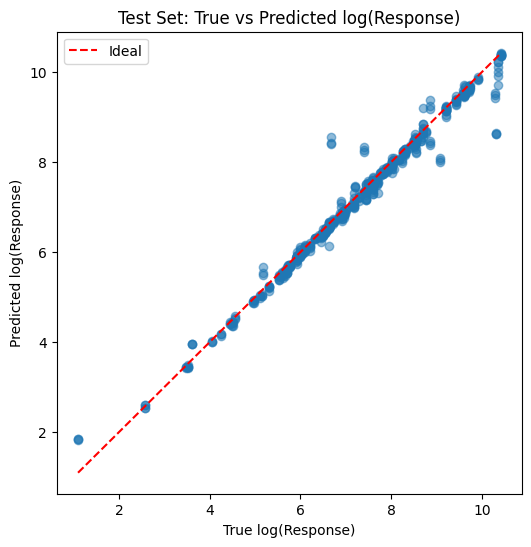

Train Set Mean Squared Error: 0.0591
Train Set R^2 Score: 0.9771


In [ ]:
# Use the correct source for true values
y_true_train = train_output_df3_QQpos_copy['log_response'].values
y_pred_train = ChemNet_MLP_train_output_df3_QQpos.cpu().numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_true_train, y_pred_train, alpha=0.5)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('Predicted log(Response)')
plt.title('Test Set: True vs Predicted log(Response)')
plt.legend()
plt.show()

mse_train = mean_squared_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
print(f"Train Set Mean Squared Error: {mse_train:.4f}")
print(f"Train Set R^2 Score: {r2_train:.4f}")

### Random forest regressor

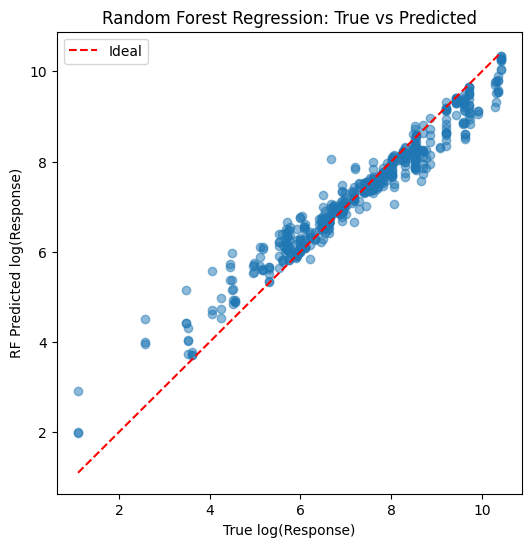

Random Forest Mean Squared Error: 0.1822
Random Forest R^2 Score: 0.9288


In [ ]:
# Prepare X and y for the Random Forest
X_rf = test_output_df3_QQpos_copy.iloc[:, :-4].select_dtypes(include=[float, int]).values
y_rf = test_output_df3_QQpos_copy['log_response'].values

# Train/test split (here, use all for both train and test for direct comparison, or split as needed)
# For demonstration, train and test on the same set
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_rf, y_rf)
y_pred_rf = rf_reg.predict(X_rf)

# Plotting
plt.figure(figsize=(6,6))
plt.scatter(y_rf, y_pred_rf, alpha=0.5)
plt.plot([y_rf.min(), y_rf.max()], [y_rf.min(), y_rf.max()], 'r--', label='Ideal')
plt.xlabel('True log(Response)')
plt.ylabel('RF Predicted log(Response)')
plt.title('Random Forest Regression: True vs Predicted')
plt.legend()
plt.show()

# Metrics
mse_rf = mean_squared_error(y_rf, y_pred_rf)
r2_rf = r2_score(y_rf, y_pred_rf)
print(f"Random Forest Mean Squared Error: {mse_rf:.4f}")
print(f"Random Forest R^2 Score: {r2_rf:.4f}")

# Spectra --> ChemNet AND Toxicity Conditional Encoder

### Architecture

In [ ]:
batch_size = 64
epochs=500
lr=0.0001
criterion1=nn.MSELoss()
criterion2=nn.MSELoss()
output_size = 513
num_layers = 8

#%%
# Encoder architecture (With Validation Set)
class Cond_Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_condenc(model, train_data, val_data, epochs, learning_rate, criterion1, criterion2, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_combined = model(batch) # Take the first 512 for criterion 1 and the last for criterion 2, look up to make sure i only apply the loss to the subset of the model
            
            # Embedding Loss
            batch_predicted_embeddings = batch_predicted_combined[:, :512] # First 512 columns
            loss1 = criterion1(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss)
            # Response Loss
            batch_predicted_log_tox = batch_predicted_combined[:, 512:] # Last column
            loss2 = criterion2(batch_predicted_log_tox, true_log_tox) # loss2 (toxicity loss)
            
            total_loss = loss1 + loss2
            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():  # Condense this as we did above for symmetry tho not needed without loss.backward command
            for val_batch, val_true_embeddings, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted = model(val_batch)
                val_batch_predicted_embeddings = val_batch_predicted[:, :512]

                val_loss = criterion1(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss1.item()

                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_tox.to(device)

                val_batch_predicted_tox = val_batch_predicted[:, 512:]

                val_loss = criterion2(val_batch_predicted_tox, val_true_tox)
                val_loss += loss2.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training and Testing set construction

In [ ]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

In [ ]:
# Add the 'Response' and 'log_response' columns to df3_QQpos_spectra
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

In [ ]:
df3_QQpos_spectra.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,672,673,674,675,676,677,678,679,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823


In [ ]:
# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data_df3_QQpos = add_response_and_log_response(train_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')
test_data_df3_QQpos = add_response_and_log_response(test_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')

# Make a copy
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 683)
(579, 683)


In [ ]:
test_data_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,673,674,675,676,677,678,679,index,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5000.000000,8.517193
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5000.000000,8.517193


In [ ]:
def create_dataset_tensors_emb_tox(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true embeddings, true toxicity values, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, log_tox_tensor, spectra_tensor, spectra_indices_tensor 

In [ ]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_emb, y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_emb_tox(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_emb, y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_emb_tox(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_emb, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_emb, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
cond_encoder_df3_QQpos = Cond_Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
cond_encoder_model_df3_QQpos = train_model_condenc(
    model=cond_encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion1=criterion1,
    criterion2=criterion2,
    device=device
)

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22149.0 MB
  Memory Used: 2067.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0
PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/500]
   Training loss: 55.069632339477536
   Validation loss: 9.881281852722168
Epoch [2/500]
   Training loss: 31.600512504577637
   Validation loss: 1.2119745016098022
Epoch [3/500]
   Training loss: 9.575532388687133
   Validation loss: 1.275824785232544
Epoch [4/500]
   Training loss: 7.0069256782531735
   Validation loss: 0.7560495734214783
Epoch [5/500]
   Training loss: 4.616932129859924
   Validation loss: 0.532633900642395
Epoch [6/500]
   Training loss: 3.460732269287109
   Validation loss: 0.7520135045051575
Epoch [7/500]
   Training loss: 2.7205834865570067
   Validation loss: 0.6736278533935547
Epoch [8/500]
   Training loss: 2.230940508842468
   Validation loss: 0.6248937845230103
Epoch [9/500]
   Training loss: 1.8702359437942504
   Vali